In [1]:
#!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 128.9 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 153.8 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


Accuracy: 0.7395833333333334


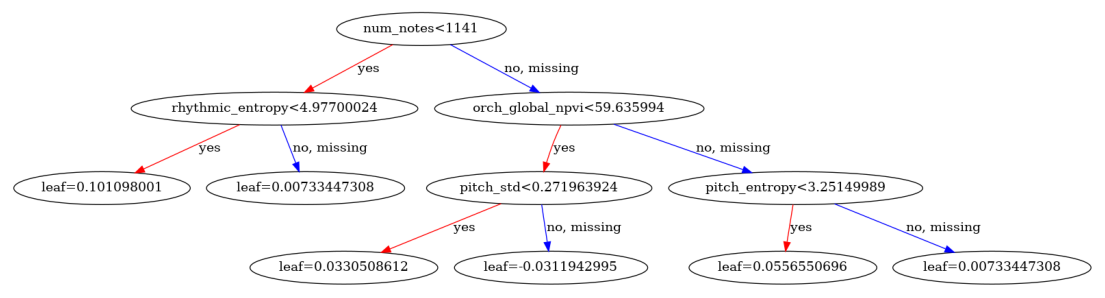

New Predictions: [0 1 1 1 1 0 1 0 1 1]
New Probabilities: [[0.8368698  0.05415906 0.01081703 0.00510656 0.05848947 0.00217471
  0.00317866 0.0087328  0.00513599 0.01533591]
 [0.10116444 0.4220971  0.06254876 0.02000262 0.01622967 0.00851845
  0.01459418 0.26538247 0.00899187 0.08047047]
 [0.14220272 0.52182126 0.07204925 0.01221309 0.00990942 0.00565238
  0.00891083 0.17106572 0.0070421  0.04913321]
 [0.0370407  0.79565996 0.01390362 0.00732383 0.00594239 0.0060448
  0.00337731 0.01252456 0.00312739 0.11505544]
 [0.13211374 0.6794317  0.04743906 0.01315437 0.01067316 0.00560201
  0.00881874 0.04898148 0.00591334 0.04787241]
 [0.88433254 0.05723067 0.01024416 0.00539618 0.00437834 0.00347413
  0.00361762 0.00922807 0.00542728 0.016671  ]
 [0.11495985 0.33252254 0.03838347 0.01693282 0.20938143 0.00925323
  0.01063954 0.17644136 0.00761189 0.08387388]
 [0.8575685  0.08284315 0.01207193 0.00523287 0.00424583 0.00310041
  0.00350814 0.00894879 0.00526302 0.01721741]
 [0.04345264 0.84164   

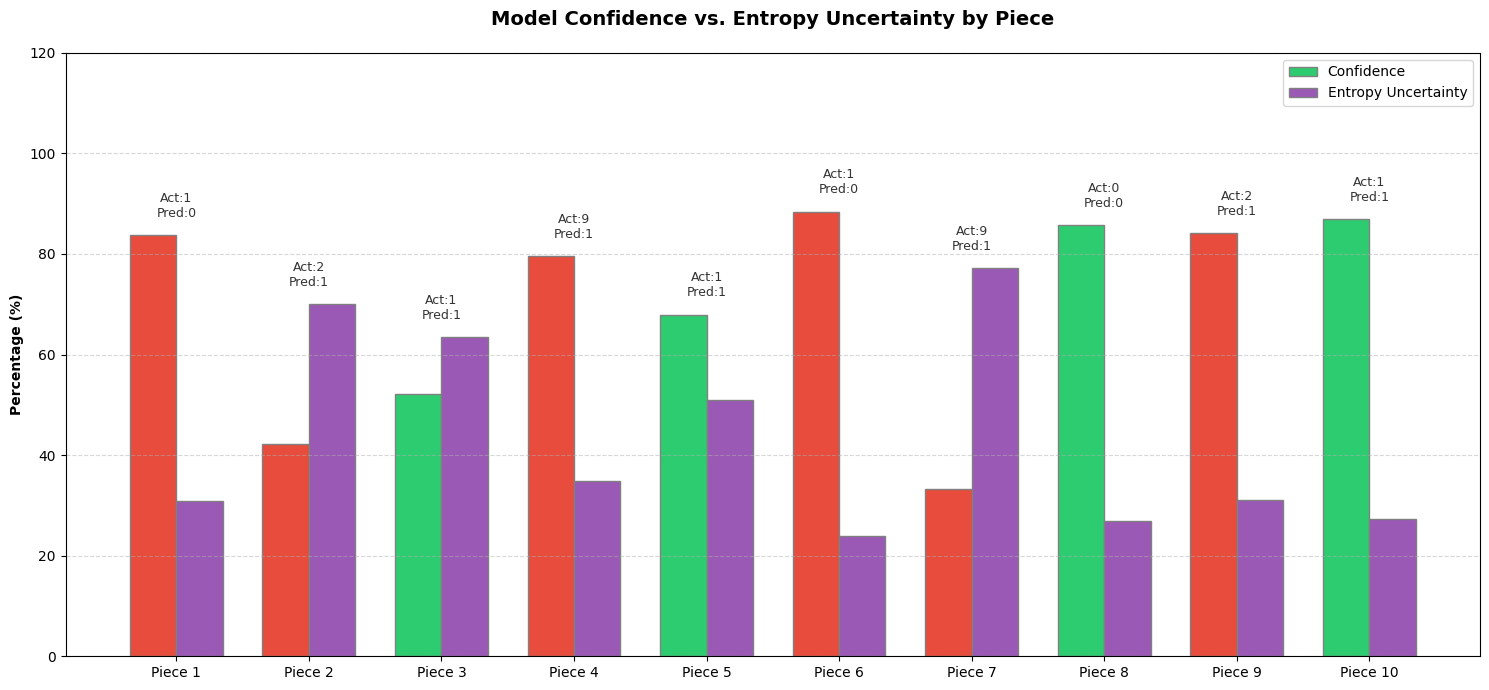

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from scipy.stats import entropy
features = ["pitch_entropy","rhythmic_entropy","average_interval_size","average_vertical_density","average_polyphonic_voices","fractal_dimension","num_notes","pitch_std","pitch_range","number_of_instruments","unique_note_values","average_beat_gap","most_common_note","average_note_length","largest_leap","orch_outer_voice_motion_index","orch_harmonic_change_entropy","orch_global_npvi"]

df = pd.read_csv('train_data.csv')

X_train, X_test, y_train, y_test = train_test_split(df[features], df["composer_label"], test_size=0.3, random_state=42)
# Train XGBoost Classifier
model = XGBClassifier(n_estimators=50, objective='multi:softprob', eval_metric="logloss", max_depth=3, num_class=10, learning_rate=0.05)
model.fit(X_train, y_train)
# Predictions and accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
# plt.figure(figsize=(30,20))
# plot_tree(model, num_trees=0)
# plt.show()

fig, ax = plt.subplots(figsize=(14, 9))   # you can also pass `sharex`, `sharey`, etc.

plot_tree(model, ax=ax)   # TB = top‑to‑bottom (default)
plt.show()


test_df = pd.read_csv('test_data_clean.csv')
separate_preds = model.predict(test_df[features])
separate_probs = model.predict_proba(test_df[features])

print("New Predictions:", separate_preds)
print("New Probabilities:", separate_probs)


num_pieces = 10
test_subset_probs = separate_probs[:num_pieces]
test_subset_preds = separate_preds[:num_pieces]

y_true_subset = df["composer_label"].iloc[:num_pieces].values 

confidence = np.max(test_subset_probs, axis=1) * 100

base_entropy = entropy(test_subset_probs, axis=1, base=2)
max_possible_entropy = np.log2(10) # 10 classes
entropy_uncertainty = (base_entropy / max_possible_entropy) * 100

x = np.arange(num_pieces)
width = 0.35 

fig, ax = plt.subplots(figsize=(15, 7))

conf_colors = ['#2ECC71' if p == t else '#E74C3C' for p, t in zip(test_subset_preds, y_true_subset)]
entropy_color = '#9B59B6'  

rects1 = ax.bar(x - width/2, confidence, width, label='Confidence', color=conf_colors, edgecolor='grey')
rects2 = ax.bar(x + width/2, entropy_uncertainty, width, label='Entropy Uncertainty', color=entropy_color, edgecolor='grey')

for i in range(num_pieces):
    act_label = y_true_subset[i]
    pred_label = test_subset_preds[i]
    
    max_y = max(confidence[i], entropy_uncertainty[i])
    ax.text(i, max_y + 3, f'Act:{act_label}\nPred:{pred_label}', 
            ha='center', va='bottom', fontsize=9, color='#333333')

ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_title('Model Confidence vs. Entropy Uncertainty by Piece', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'Piece {i+1}' for i in range(num_pieces)])
ax.set_ylim(0, 120)  # Extra headroom for labels

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ECC71', edgecolor='grey', label='Confidence'),
    Patch(facecolor='#9B59B6', edgecolor='grey', label='Entropy Uncertainty')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()